In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharthj08/amazon-product-review-sentiment-analysis-using-nlp/Reviews.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [6]:
data = pd.read_csv("/kaggle/input/datasets/siddharthj08/amazon-product-review-sentiment-analysis-using-nlp/Reviews.csv")

print(data.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [7]:
print(data.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [21]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

In [22]:
data['Sentiment'] = data['Score'].apply(sentiment_label)

In [23]:
print(data[['Score', 'Sentiment']].head())


   Score Sentiment
0      5  positive
1      1  negative
2      4  positive
3      2  negative
4      5  positive


In [24]:
data = data[['Text', 'Sentiment']]

In [25]:
print(data.head())

                                                Text Sentiment
0  I have bought several of the Vitality canned d...  positive
1  Product arrived labeled as Jumbo Salted Peanut...  negative
2  This is a confection that has been around a fe...  positive
3  If you are looking for the secret ingredient i...  negative
4  Great taffy at a great price.  There was a wid...  positive


In [26]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    return text

In [27]:
data['Text'] = data['Text'].apply(clean_text)

In [28]:
print(data.head())

                                                Text Sentiment
0  i have bought several of the vitality canned d...  positive
1  product arrived labeled as jumbo salted peanut...  negative
2  this is a confection that has been around a fe...  positive
3  if you are looking for the secret ingredient i...  negative
4  great taffy at a great price   there was a wid...  positive


In [29]:
X = data['Text']

y = data['Sentiment']

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [34]:
predictions = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.80061746312373


In [43]:
review = ["This product is amazing"]

review_vector = vectorizer.transform(review)

result = model.predict(review_vector)

print(result)

['positive']


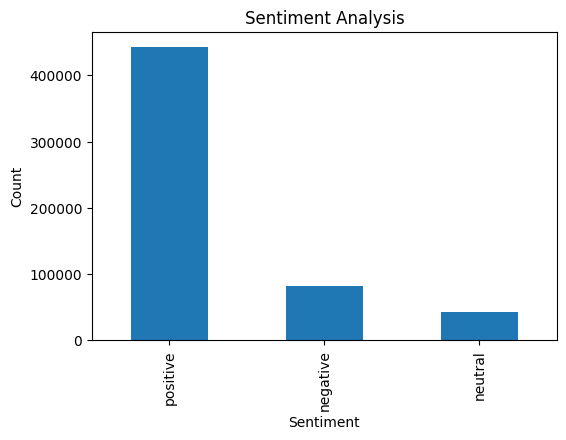

In [47]:
data['Sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()